# Entendimiento de datos

**Conjunto de datos:** Dataset 5 - Matriz Variable - Tipo de fuente

**Nombre de archivo:** air_source_matrix.csv

## 0. Inicialización

### 0.1. Perfilamiento de datos

Instalar ydata-profiling

In [1]:
!pip install ydata-profiling

Importaciones

In [2]:
import pandas as pd
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns

import re
from tabulate import tabulate

Visualización de tablas y gráficas

In [3]:
sns.set_style("darkgrid")

def print_table(df):
    print(tabulate(df, headers='keys', tablefmt='simple_outline'))

Lectura y muestra del archivo

In [4]:
df = pd.read_csv("../data/enriquecida/air_source_matrix.csv")
df.head()

,Variable,Tipo de fuente,Probabilidad,Justificación,Ponderación
0,SO2,Sin definir,4,Emisiones de SO₂ suelen asociarse a combustión...,0.4
1,SO2,Horno,7,Hornos que queman combustibles fósiles o coque...,0.4
2,SO2,Caldera,8,Calderas industriales queman combustibles (res...,0.4
3,SO2,Caldera horno,8,Combina características de caldera y horno — a...,0.4
4,SO2,Planta de asfalto,6,Uso de combustibles bituminosos y procesos de ...,0.4


Información del archivo (Cantidad de filas, cantidad de columnas y tipos de dato)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Variable        84 non-null     object 
 1   Tipo de fuente  84 non-null     object 
 2   Probabilidad    84 non-null     int64  
 3   Justificación   84 non-null     object 
 4   Ponderación     84 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 3.4+ KB


Columnas agrupadas por tipo de dato

In [6]:
columnas_por_tipo = df.columns.to_series().groupby(df.dtypes).groups

print("Columnas agrupadas por tipo de dato:\n")
for tipo, cols in columnas_por_tipo.items():
    print(f"{tipo} ({len(cols)} columnas): {', '.join(cols)}")

Columnas agrupadas por tipo de dato:

int64 (1 columnas): Probabilidad
float64 (1 columnas): Ponderación
object (3 columnas): Variable, Tipo de fuente, Justificación


## 1. Variables categóricas

Variables categóricas encontradas

In [7]:
non_numeric_attributes = ["Variable", "Tipo de fuente"]
pd.DataFrame(non_numeric_attributes, columns=['Non Numeric Attributes'])

,Non Numeric Attributes
0,Variable
1,Tipo de fuente


Conteos y porcentajes para cada valor único en las columnas. 

In [8]:
for col in non_numeric_attributes:
    attribute = df[col].value_counts()
    df_attribute = pd.DataFrame({
        f"{col} values": attribute.index,
        'Count': attribute.values,
        'Percentage (%)': attribute.values * 100 / attribute.values.sum()
    }).sort_values(by='Count', ascending=False)

    print_table(df_attribute)

┌────┬───────────────────┬─────────┬──────────────────┐
│    │ Variable values   │   Count │   Percentage (%) │
├────┼───────────────────┼─────────┼──────────────────┤
│  0 │ SO2               │      12 │          14.2857 │
│  1 │ PM2.5             │      12 │          14.2857 │
│  2 │ NO2               │      12 │          14.2857 │
│  3 │ CO                │      12 │          14.2857 │
│  4 │ NO                │      12 │          14.2857 │
│  5 │ PM10              │      12 │          14.2857 │
│  6 │ NOX               │      12 │          14.2857 │
└────┴───────────────────┴─────────┴──────────────────┘
┌────┬───────────────────────────────┬─────────┬──────────────────┐
│    │ Tipo de fuente values         │   Count │   Percentage (%) │
├────┼───────────────────────────────┼─────────┼──────────────────┤
│  0 │ Sin definir                   │       7 │          8.33333 │
│  1 │ Horno                         │       7 │          8.33333 │
│  2 │ Caldera                       │      

**Hallazgos:**

- Hay 15 variables y 12 tipos de fuente, tal como la cantidad de datos útiles en los otros datasets

## 2. Variables numéricas

Variables numéricas encontradas

In [9]:
numeric_attributes = df.select_dtypes(include=['number']).columns.values
pd.DataFrame(numeric_attributes, columns=['Numeric Attributes'])

,Numeric Attributes
0,Probabilidad
1,Ponderación


Conteo de filas, promedio, desviación estándar, valores mínimo y máximo junto a los cuartiles

In [10]:
df[numeric_attributes].describe()

,Probabilidad,Ponderación
count,84.000000,84.000000
mean,5.571429,0.457143
std,2.455806,0.090893
min,1.000000,0.400000
25%,4.000000,0.400000
50%,6.000000,0.400000
75%,8.000000,0.600000
max,9.000000,0.600000


Visualización de esta información con diagramas de caja

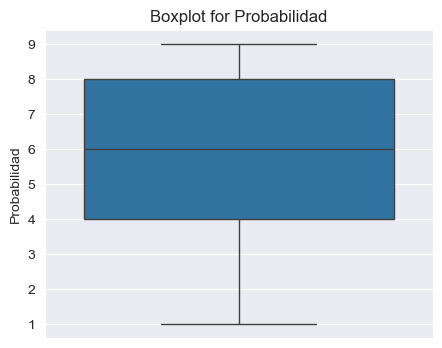

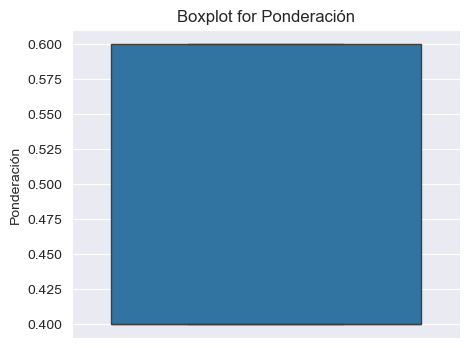

In [11]:
for col in numeric_attributes:
    plt.figure(figsize=(5,4))
    ax = sns.boxplot(data=df[col])
    ax.set_title(f"Boxplot for {col}")
    plt.xticks(rotation=45)
    plt.show()

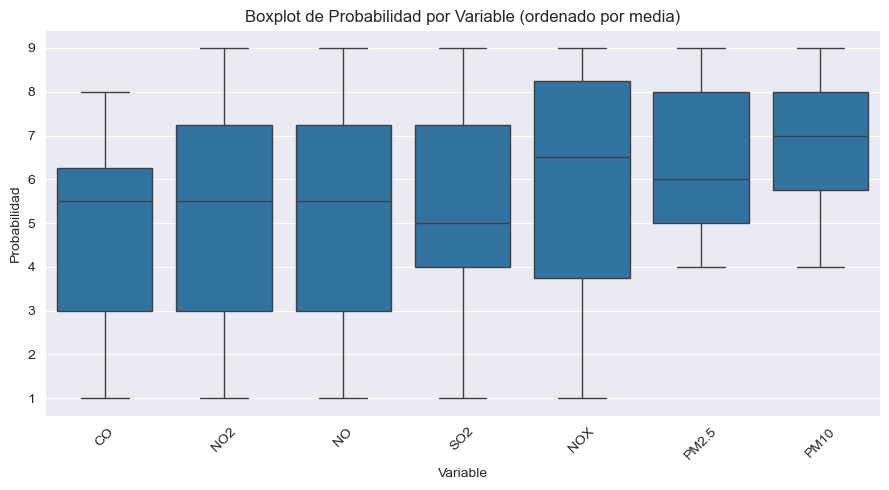

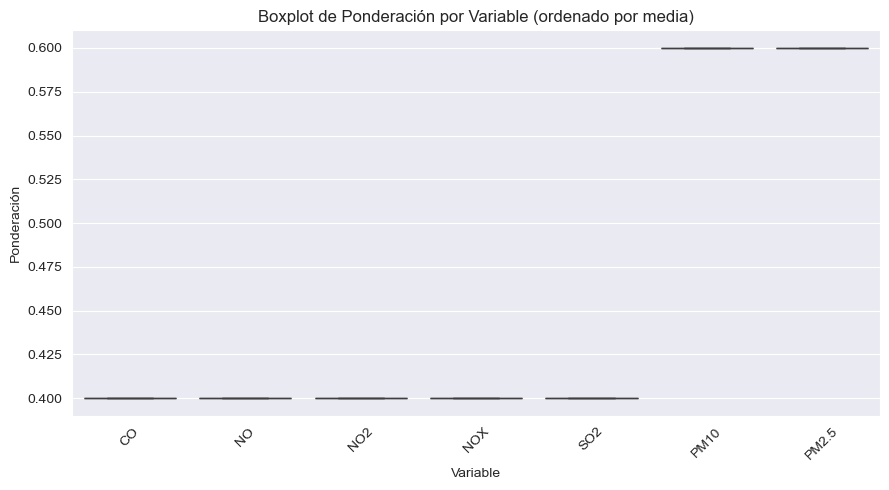

In [12]:
for col in numeric_attributes:
    # Calcular el orden de las categorías por la media de cada Variable
    order = (
        df.groupby("Variable")[col]
        .mean()
        .sort_values(ascending=True)  # o ascending=True si quieres de menor a mayor
        .index
    )

    plt.figure(figsize=(9, 5))
    ax = sns.boxplot(data=df, x="Variable", y=col, order=order)
    ax.set_title(f"Boxplot de {col} por Variable (ordenado por media)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

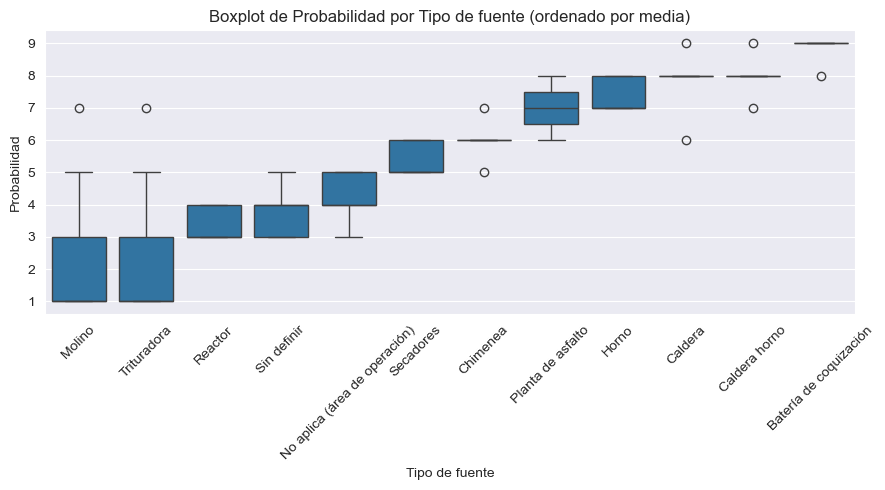

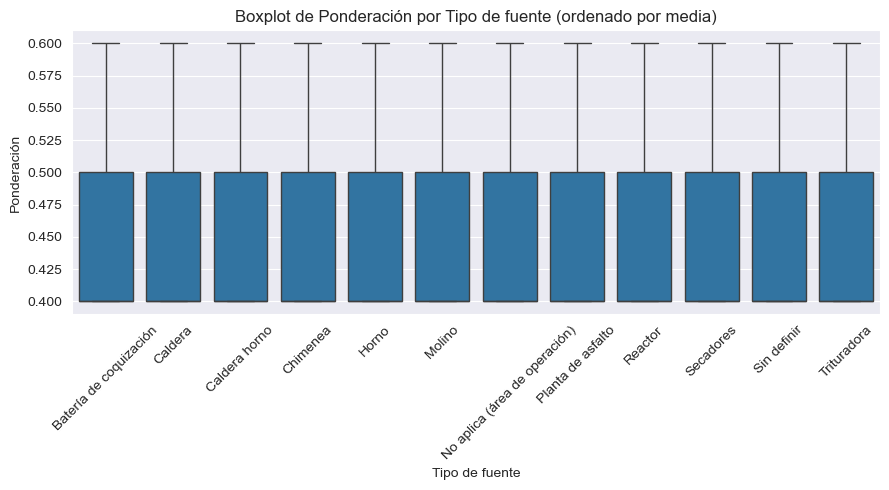

In [13]:
for col in numeric_attributes:
    # Calcular el orden de las categorías por la media de cada Variable
    order = (
        df.groupby("Tipo de fuente")[col]
        .mean()
        .sort_values(ascending=True)  # o ascending=True si quieres de menor a mayor
        .index
    )

    plt.figure(figsize=(9, 5))
    ax = sns.boxplot(data=df, x="Tipo de fuente", y=col, order=order)
    ax.set_title(f"Boxplot de {col} por Tipo de fuente (ordenado por media)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Histogramas para visualizar la distribución de cada columna

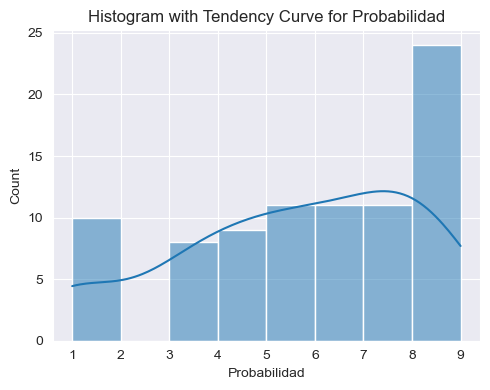

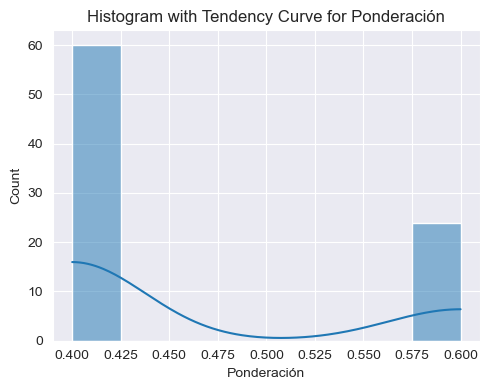

In [14]:
for col in df[numeric_attributes]:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram with Tendency Curve for {col}")
    plt.tight_layout()
    plt.show()

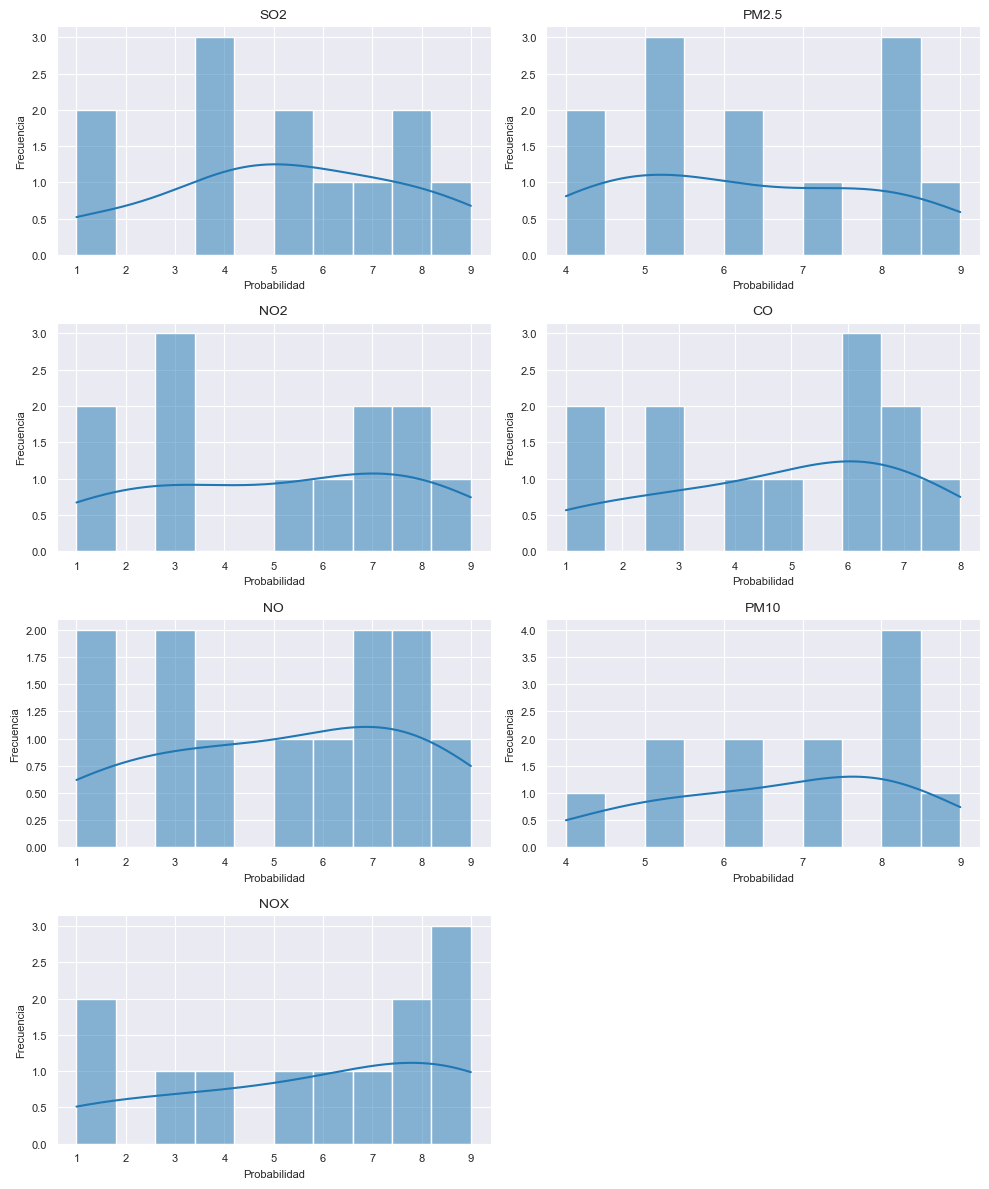

In [15]:
variables_unicas = df['Variable'].unique()
n_vars = len(variables_unicas)

# Calcular grid de subplots con 2 columnas
n_cols = 2
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows*3))
axes = axes.flatten()

for idx, variable in enumerate(variables_unicas):
    datos_variable = df[df['Variable'] == variable]['Probabilidad']
    sns.histplot(datos_variable, kde=True, bins=10, ax=axes[idx])
    axes[idx].set_title(f"{variable}", fontsize=10)
    axes[idx].set_xlabel("Probabilidad", fontsize=8)
    axes[idx].set_ylabel("Frecuencia", fontsize=8)
    axes[idx].tick_params(labelsize=8)

# Ocultar subplots vacíos
for idx in range(len(variables_unicas), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

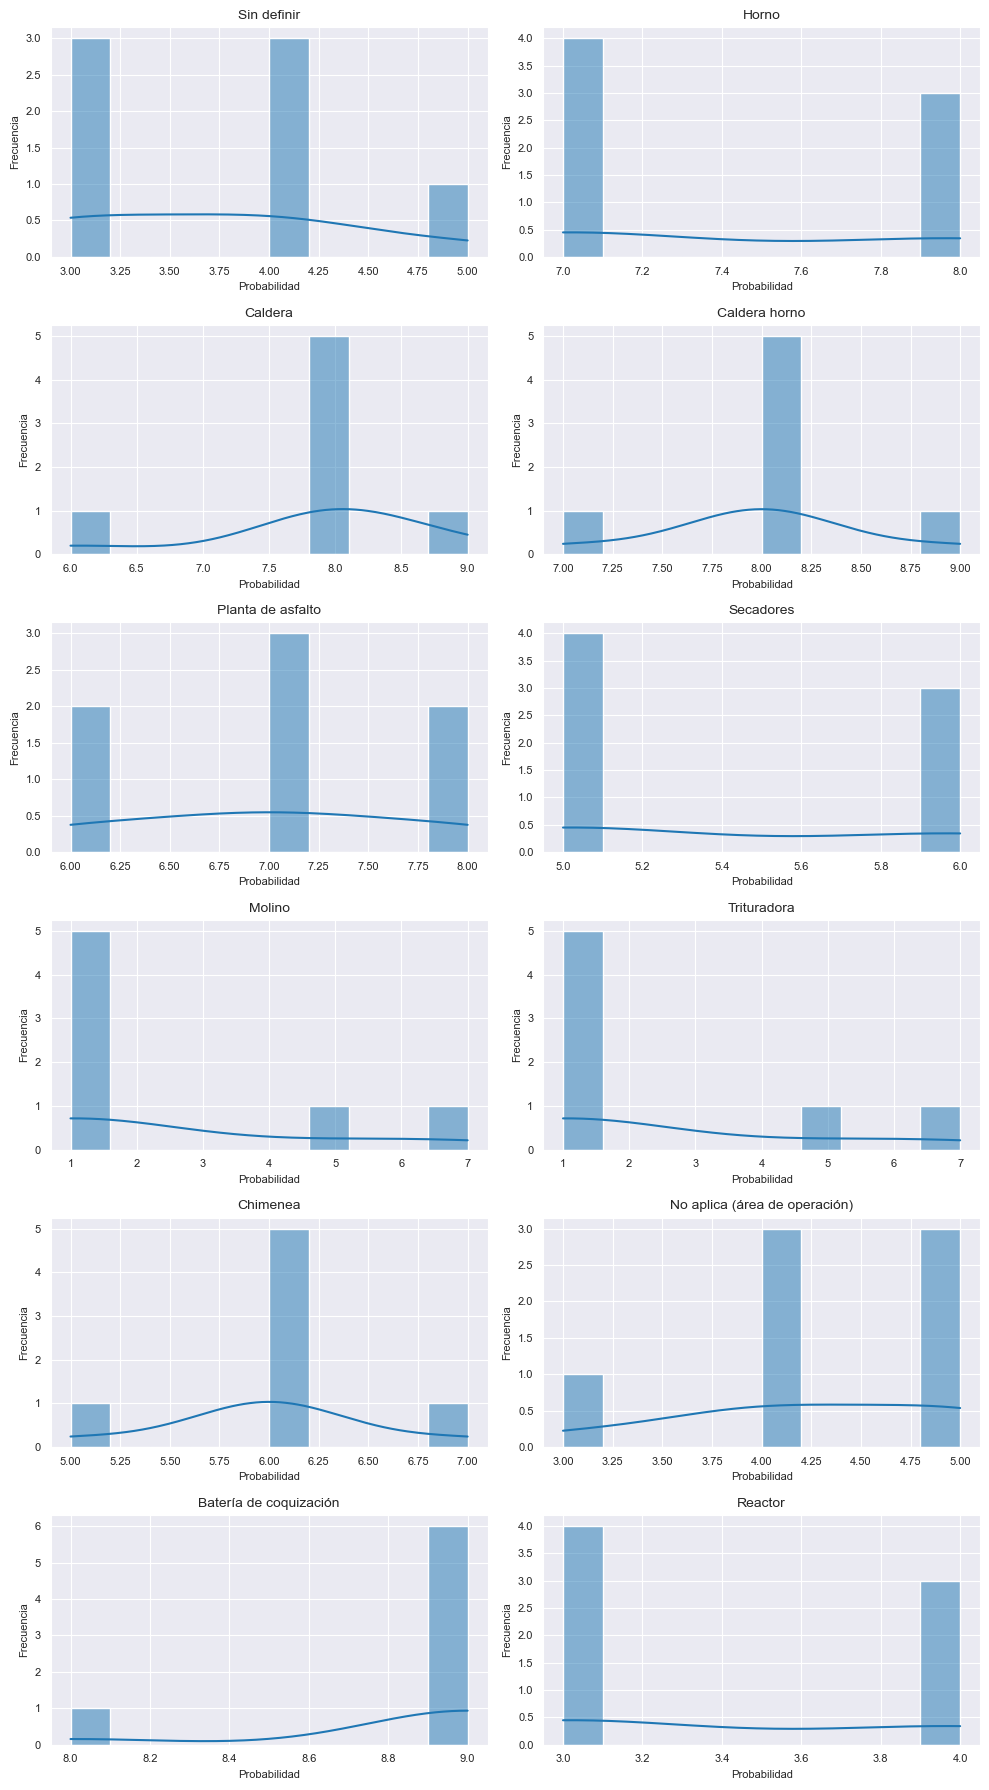

In [16]:
variables_unicas = df['Tipo de fuente'].unique()
n_vars = len(variables_unicas)

# Calcular grid de subplots con 2 columnas
n_cols = 2
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows*3))
axes = axes.flatten()

for idx, variable in enumerate(variables_unicas):
    datos_variable = df[df['Tipo de fuente'] == variable]['Probabilidad']
    sns.histplot(datos_variable, kde=True, bins=10, ax=axes[idx])
    axes[idx].set_title(f"{variable}", fontsize=10)
    axes[idx].set_xlabel("Probabilidad", fontsize=8)
    axes[idx].set_ylabel("Frecuencia", fontsize=8)
    axes[idx].tick_params(labelsize=8)

# Ocultar subplots vacíos
for idx in range(len(variables_unicas), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 4.  Análisis adicionales

Se puede efectuar un Pandas Profiling para encontrar más información

En especial, son de gran interés las correlaciones y las interacciones entre variables

In [17]:
reporte = ProfileReport(df)
reporte.to_file("archivos_generados/Reporte perfilamiento - Dataset 5.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 233.39it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

**Hallazgos:**

Características de las variables:

- Probabilidad tiene 24 (13.3%) ceros

Correlaciones:

- La correlación positiva entre la Variable y la Probabilidad es baja (0.3)
- La correlación positiva entre el Tipo de fuente y la Probabilidad es baja (0.33)